# Análise de Táxis em Nova York

## Pergunta de Análise

Qual a média de passageiros (**passenger_count**) por cada hora do dia que pegaram táxi no mês de maio considerando todos os táxis da frota?

### Contexto
Este notebook analisa dados de táxis em Nova York, focando no comportamento de passageiros ao longo do dia durante o mês de maio. A análise considera toda a frota disponível para identificar padrões de demanda horária.

### Objetivo
- Calcular a média de passageiros por hora do dia
- Filtrar dados do mês de maio
- Visualizar tendências horárias de ocupação de táxis
- Identificar períodos de pico e baixa demanda

In [124]:
%pip install matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [126]:
from ifood.aws.athena_queries import execute_athena_query
from ifood.vars import athena_output_queries

In [127]:
athena_schema = "ifood_nyc_taxi_agency"
athena_yellow_table = "yellow_tripdata"
athena_green_table = "green_tripdata"

In [128]:
query = f"""
WITH green_data AS (
    SELECT vendorid, AVG(passenger_count) as passenger_count 
    FROM {athena_schema}.{athena_green_table} 
    GROUP BY vendorid
),

yellow_data AS (
    SELECT vendorid, tpep_pickup_datetime, passenger_count 
    FROM {athena_schema}.{athena_yellow_table} 
    WHERE date_format(tpep_pickup_datetime, '%Y-%m') = '2023-05'
)

SELECT
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d %H') AS pickup_hour,
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d') AS pickup_date,
    ROUND(AVG(y.passenger_count + g.passenger_count),2) AS avg_passenger_count
FROM yellow_data as y
LEFT JOIN green_data as g
ON y.vendorid = g.vendorid
GROUP BY 1, 2
ORDER BY 1
"""

In [129]:
results = execute_athena_query(query, athena_output_queries)

In [130]:
results

[{'pickup_hour': '2023-05-01 00',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.66'},
 {'pickup_hour': '2023-05-01 01',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.62'},
 {'pickup_hour': '2023-05-01 02',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.62'},
 {'pickup_hour': '2023-05-01 03',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.57'},
 {'pickup_hour': '2023-05-01 04',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.59'},
 {'pickup_hour': '2023-05-01 05',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.62'},
 {'pickup_hour': '2023-05-01 06',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.65'},
 {'pickup_hour': '2023-05-01 07',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.6'},
 {'pickup_hour': '2023-05-01 08',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.49'},
 {'pickup_hour': '2023-05-01 09',
  'pickup_date': '2023-05-01',
  'avg_passenger_count': '2.46'},
 {'pickup_h

In [131]:
df = pd.DataFrame(results)
df['avg_passenger_count'] = pd.to_numeric(df['avg_passenger_count'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_date', 'avg_passenger_count'], ascending=False)

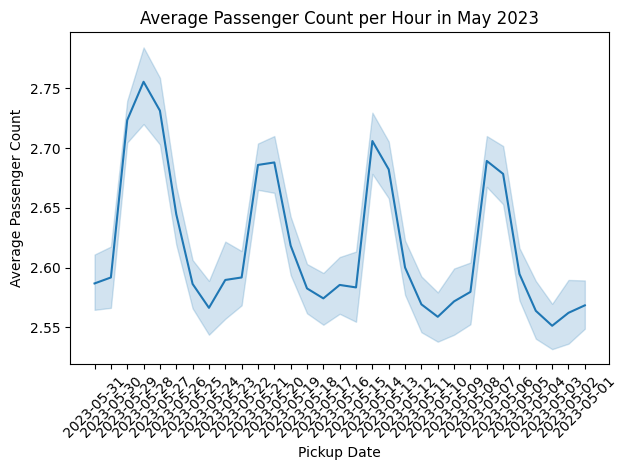

In [132]:
sns.lineplot(data=df_avg, x='pickup_date', y='avg_passenger_count')
plt.xticks(rotation=45)
plt.title('Average Passenger Count per Hour in May 2023')
plt.xlabel('Pickup Date')
plt.ylabel('Average Passenger Count')
plt.tight_layout()
plt.show()

In [133]:
query = f"""
WITH green_data AS (
    SELECT vendorid, AVG(passenger_count) as passenger_count 
    FROM {athena_schema}.{athena_green_table} 
    GROUP BY vendorid
),

yellow_data AS (
    SELECT vendorid, tpep_pickup_datetime, passenger_count 
    FROM {athena_schema}.{athena_yellow_table} 
    WHERE date_format(tpep_pickup_datetime, '%Y-%m') = '2023-05'
),

get_data AS (
    SELECT
        date_format(y.tpep_pickup_datetime, '%Y-%m-%d %H') AS pickup_hour,
        date_format(y.tpep_pickup_datetime, '%Y-%m-%d') AS pickup_date,
        ROUND(AVG(y.passenger_count + g.passenger_count),2) AS avg_passenger_count
    FROM yellow_data as y
    LEFT JOIN green_data as g
    ON y.vendorid = g.vendorid
    GROUP BY 1, 2
    ORDER BY 1
)

SELECT
    pickup_date,
    ROUND(SUM(avg_passenger_count),2) AS total_avg_passenger_count
FROM get_data
GROUP BY pickup_date
ORDER BY total_avg_passenger_count DESC
"""

In [134]:
results = execute_athena_query(query, athena_output_queries)

In [135]:
results

[{'pickup_date': '2023-05-28', 'total_avg_passenger_count': '66.13'},
 {'pickup_date': '2023-05-27', 'total_avg_passenger_count': '65.55'},
 {'pickup_date': '2023-05-29', 'total_avg_passenger_count': '65.36'},
 {'pickup_date': '2023-05-14', 'total_avg_passenger_count': '64.94'},
 {'pickup_date': '2023-05-07', 'total_avg_passenger_count': '64.54'},
 {'pickup_date': '2023-05-20', 'total_avg_passenger_count': '64.51'},
 {'pickup_date': '2023-05-21', 'total_avg_passenger_count': '64.46'},
 {'pickup_date': '2023-05-13', 'total_avg_passenger_count': '64.37'},
 {'pickup_date': '2023-05-06', 'total_avg_passenger_count': '64.28'},
 {'pickup_date': '2023-05-26', 'total_avg_passenger_count': '63.47'},
 {'pickup_date': '2023-05-19', 'total_avg_passenger_count': '62.84'},
 {'pickup_date': '2023-05-12', 'total_avg_passenger_count': '62.4'},
 {'pickup_date': '2023-05-05', 'total_avg_passenger_count': '62.27'},
 {'pickup_date': '2023-05-30', 'total_avg_passenger_count': '62.2'},
 {'pickup_date': '2023

In [136]:
df = pd.DataFrame(results)
df['total_avg_passenger_count'] = pd.to_numeric(df['total_avg_passenger_count'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_date', 'total_avg_passenger_count'], ascending=False)

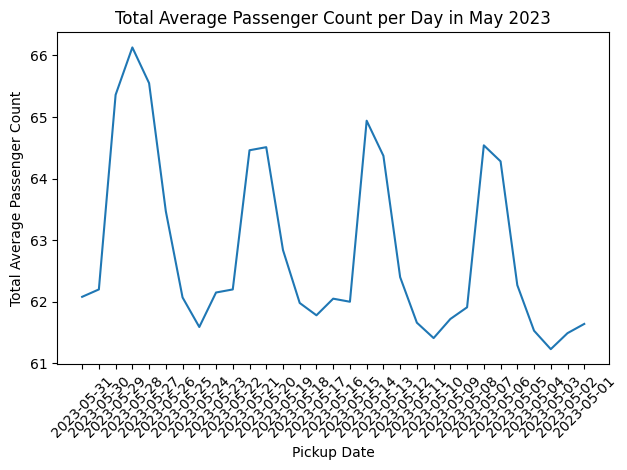

In [137]:
sns.lineplot(data=df_avg, x='pickup_date', y='total_avg_passenger_count')
plt.xticks(rotation=45)
plt.title('Total Average Passenger Count per Day in May 2023')
plt.xlabel('Pickup Date')
plt.ylabel('Total Average Passenger Count')
plt.tight_layout()
plt.show()

In [138]:
query = f"""
WITH green_data AS (
    SELECT vendorid, AVG(passenger_count) as passenger_count 
    FROM {athena_schema}.{athena_green_table} 
    GROUP BY vendorid
),

yellow_data AS (
    SELECT vendorid, tpep_pickup_datetime, passenger_count 
    FROM {athena_schema}.{athena_yellow_table} 
    WHERE date_format(tpep_pickup_datetime, '%Y-%m') = '2023-05'
)

SELECT
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d %H') AS pickup_hour,
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d') AS pickup_date,
    ROUND(AVG(y.passenger_count + g.passenger_count),2) AS avg_passenger_count
FROM yellow_data as y
LEFT JOIN green_data as g
ON y.vendorid = g.vendorid
WHERE date_format(y.tpep_pickup_datetime, '%Y-%m-%d') = '2023-05-28'
GROUP BY 1, 2
ORDER BY 1
"""

In [139]:
results = execute_athena_query(query, athena_output_queries)

In [140]:
results

[{'pickup_hour': '2023-05-28 00',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.83'},
 {'pickup_hour': '2023-05-28 01',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.84'},
 {'pickup_hour': '2023-05-28 02',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.78'},
 {'pickup_hour': '2023-05-28 03',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.78'},
 {'pickup_hour': '2023-05-28 04',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.78'},
 {'pickup_hour': '2023-05-28 05',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.8'},
 {'pickup_hour': '2023-05-28 06',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.75'},
 {'pickup_hour': '2023-05-28 07',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.72'},
 {'pickup_hour': '2023-05-28 08',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.61'},
 {'pickup_hour': '2023-05-28 09',
  'pickup_date': '2023-05-28',
  'avg_passenger_count': '2.51'},
 {'pickup_h

In [144]:
df = pd.DataFrame(results)
df['avg_passenger_count'] = pd.to_numeric(df['avg_passenger_count'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_hour', 'avg_passenger_count'], ascending=False)

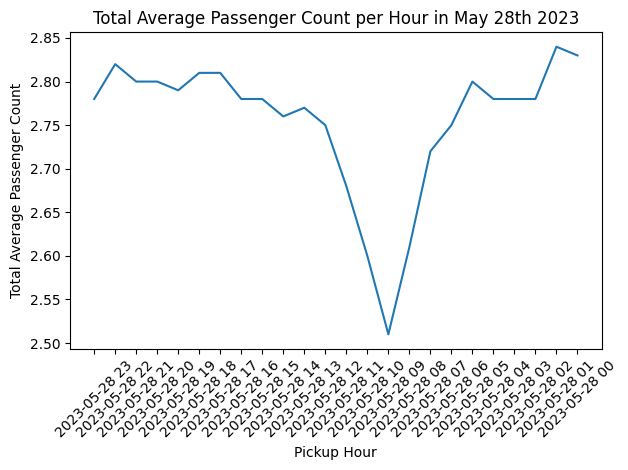

In [145]:
sns.lineplot(data=df_avg, x='pickup_hour', y='avg_passenger_count')
plt.xticks(rotation=45)
plt.title('Total Average Passenger Count per Hour in May 28th 2023')
plt.xlabel('Pickup Hour')
plt.ylabel('Total Average Passenger Count')
plt.tight_layout()
plt.show()

In [146]:
query = f"""
WITH green_data AS (
    SELECT vendorid, AVG(passenger_count) as passenger_count 
    FROM {athena_schema}.{athena_green_table} 
    GROUP BY vendorid
),

yellow_data AS (
    SELECT vendorid, tpep_pickup_datetime, passenger_count 
    FROM {athena_schema}.{athena_yellow_table} 
    WHERE date_format(tpep_pickup_datetime, '%Y-%m') = '2023-05'
)

SELECT
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d %H') AS pickup_hour,
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d') AS pickup_date,
    ROUND(AVG(y.passenger_count + g.passenger_count),2) AS avg_passenger_count
FROM yellow_data as y
LEFT JOIN green_data as g
ON y.vendorid = g.vendorid
WHERE date_format(y.tpep_pickup_datetime, '%Y-%m-%d') = '2023-05-03'
GROUP BY 1, 2
ORDER BY 1
"""

In [147]:
results = execute_athena_query(query, athena_output_queries)

In [148]:
results

[{'pickup_hour': '2023-05-03 00',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.61'},
 {'pickup_hour': '2023-05-03 01',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.62'},
 {'pickup_hour': '2023-05-03 02',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.62'},
 {'pickup_hour': '2023-05-03 03',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.61'},
 {'pickup_hour': '2023-05-03 04',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.61'},
 {'pickup_hour': '2023-05-03 05',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.58'},
 {'pickup_hour': '2023-05-03 06',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.61'},
 {'pickup_hour': '2023-05-03 07',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.53'},
 {'pickup_hour': '2023-05-03 08',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.46'},
 {'pickup_hour': '2023-05-03 09',
  'pickup_date': '2023-05-03',
  'avg_passenger_count': '2.46'},
 {'pickup_

In [149]:
df = pd.DataFrame(results)
df['avg_passenger_count'] = pd.to_numeric(df['avg_passenger_count'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_hour', 'avg_passenger_count'], ascending=False)

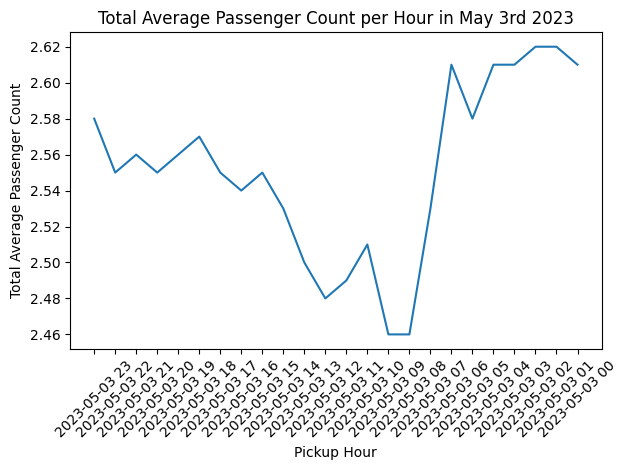

In [151]:
sns.lineplot(data=df_avg, x='pickup_hour', y='avg_passenger_count')
plt.xticks(rotation=45)
plt.title('Total Average Passenger Count per Hour in May 3rd 2023')
plt.xlabel('Pickup Hour')
plt.ylabel('Total Average Passenger Count')
plt.tight_layout()
plt.show()

In [152]:
query = f"""
WITH green_data AS (
    SELECT vendorid, AVG(passenger_count) as passenger_count 
    FROM {athena_schema}.{athena_green_table} 
    GROUP BY vendorid
),

yellow_data AS (
    SELECT vendorid, tpep_pickup_datetime, passenger_count 
    FROM {athena_schema}.{athena_yellow_table} 
    WHERE date_format(tpep_pickup_datetime, '%Y-%m') = '2023-05'
)

SELECT
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d %H') AS pickup_hour,
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d') AS pickup_date,
    ROUND(AVG(y.passenger_count + g.passenger_count),2) AS avg_passenger_count
FROM yellow_data as y
LEFT JOIN green_data as g
ON y.vendorid = g.vendorid
WHERE date_format(y.tpep_pickup_datetime, '%Y-%m-%d') = '2023-05-27'
GROUP BY 1, 2
ORDER BY 1
"""

In [153]:
results = execute_athena_query(query, athena_output_queries)

In [154]:
results

[{'pickup_hour': '2023-05-27 00',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.76'},
 {'pickup_hour': '2023-05-27 01',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.78'},
 {'pickup_hour': '2023-05-27 02',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.77'},
 {'pickup_hour': '2023-05-27 03',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.74'},
 {'pickup_hour': '2023-05-27 04',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.72'},
 {'pickup_hour': '2023-05-27 05',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.73'},
 {'pickup_hour': '2023-05-27 06',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.73'},
 {'pickup_hour': '2023-05-27 07',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.67'},
 {'pickup_hour': '2023-05-27 08',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.67'},
 {'pickup_hour': '2023-05-27 09',
  'pickup_date': '2023-05-27',
  'avg_passenger_count': '2.52'},
 {'pickup_

In [155]:
df = pd.DataFrame(results)
df['avg_passenger_count'] = pd.to_numeric(df['avg_passenger_count'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_hour', 'avg_passenger_count'], ascending=False)

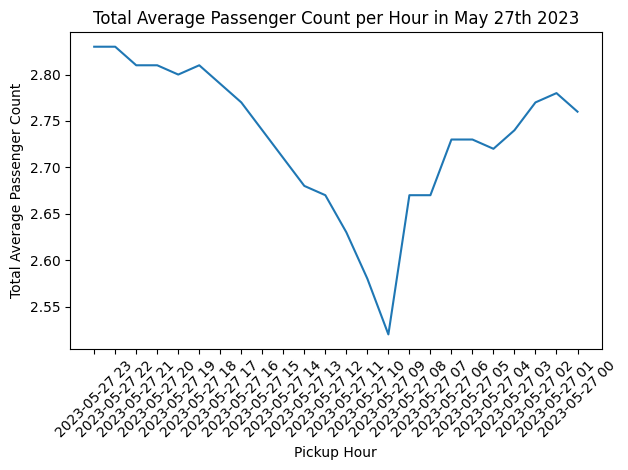

In [156]:
sns.lineplot(data=df_avg, x='pickup_hour', y='avg_passenger_count')
plt.xticks(rotation=45)
plt.title('Total Average Passenger Count per Hour in May 27th 2023')
plt.xlabel('Pickup Hour')
plt.ylabel('Total Average Passenger Count')
plt.tight_layout()
plt.show()

In [157]:
query = f"""
WITH green_data AS (
    SELECT vendorid, AVG(passenger_count) as passenger_count 
    FROM {athena_schema}.{athena_green_table} 
    GROUP BY vendorid
),

yellow_data AS (
    SELECT vendorid, tpep_pickup_datetime, passenger_count 
    FROM {athena_schema}.{athena_yellow_table} 
    WHERE date_format(tpep_pickup_datetime, '%Y-%m') = '2023-05'
)

SELECT
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d %H') AS pickup_hour,
    date_format(y.tpep_pickup_datetime, '%Y-%m-%d') AS pickup_date,
    ROUND(AVG(y.passenger_count + g.passenger_count),2) AS avg_passenger_count
FROM yellow_data as y
LEFT JOIN green_data as g
ON y.vendorid = g.vendorid
WHERE date_format(y.tpep_pickup_datetime, '%Y-%m-%d') = '2023-05-10'
GROUP BY 1, 2
ORDER BY 1
"""

In [158]:
results = execute_athena_query(query, athena_output_queries)

In [159]:
results

[{'pickup_hour': '2023-05-10 00',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.59'},
 {'pickup_hour': '2023-05-10 01',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.62'},
 {'pickup_hour': '2023-05-10 02',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.62'},
 {'pickup_hour': '2023-05-10 03',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.62'},
 {'pickup_hour': '2023-05-10 04',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.62'},
 {'pickup_hour': '2023-05-10 05',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.65'},
 {'pickup_hour': '2023-05-10 06',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.61'},
 {'pickup_hour': '2023-05-10 07',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.59'},
 {'pickup_hour': '2023-05-10 08',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.5'},
 {'pickup_hour': '2023-05-10 09',
  'pickup_date': '2023-05-10',
  'avg_passenger_count': '2.45'},
 {'pickup_h

In [160]:
df = pd.DataFrame(results)
df['avg_passenger_count'] = pd.to_numeric(df['avg_passenger_count'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_hour', 'avg_passenger_count'], ascending=False)

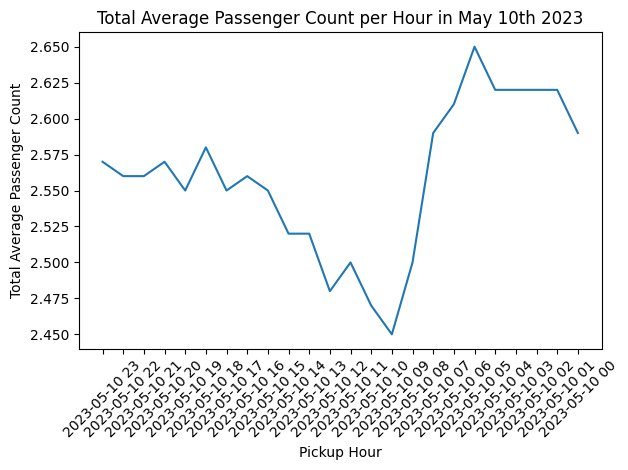

In [161]:
sns.lineplot(data=df_avg, x='pickup_hour', y='avg_passenger_count')
plt.xticks(rotation=45)
plt.title('Total Average Passenger Count per Hour in May 10th 2023')
plt.xlabel('Pickup Hour')
plt.ylabel('Total Average Passenger Count')
plt.tight_layout()
plt.show()